# Practical Session 01d &mdash; Train / validation / test: the split that keeps you honest

**Companion to Lecture&nbsp;01.** Notebook 01c ended with one rule: *split before you transform.*
This notebook is about the deeper reason that rule exists &mdash; **honest evaluation** &mdash; and the
single most misunderstood idea in applied ML: **why you need a validation set that is separate
from the test set.**

> ⭐ **The one sentence to remember.** *Any set you use to make a decision, you fit to &mdash;
> including the decision "which model is best."* So the set you use to **choose** (validation)
> must be different from the set you use to report an **honest final number** (test).

The lecture's exam analogy is the anchor:

| split | role | how often you look at it |
|-------|------|--------------------------|
| **train** | fit the model's parameters | constantly (that's what fitting *is*) |
| **validation** | choose the model, hyperparameters, features; decide when to stop | many times |
| **test** | one honest estimate of real-world performance | **exactly once** |

Studying from the homework (train), rehearsing on practice exams (validation), then sitting the
real final once (test). Peeking at the final's questions while you "practice" is *exactly* what
tuning on the test set is &mdash; and this notebook shows, with experiments, how badly it fools you.

*Run each cell (Shift+Enter). Self-contained and offline.*

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from nb_utils import use_style
from nb_data import make_apartments, basic_clean

use_style("notes")
rng = np.random.default_rng(0)
print("ready")

ready


## 1. Making the three-way split

We use the apartments data from 01a/01c, cleaned. We hold out a **test** set now and never
touch it until the very end. To *see* honesty later, we also imagine that **new apartments
arrive next month** &mdash; a genuinely fresh sample (a different random draw), which we will use to
check whether our reported numbers were honest.

In [2]:
from sklearn.model_selection import train_test_split

df = basic_clean(make_apartments(n=1500, seed=0, messy=True))
df["has_elevator"] = df["has_elevator"].astype(int)
X, y = df.drop(columns="rent_eur"), df["rent_eur"]

# dev = train + validation; test is held out and untouched until section 4
X_dev, X_test, y_dev, y_test = train_test_split(X, y, test_size=0.20, random_state=0)
X_train, X_val, y_train, y_val = train_test_split(X_dev, y_dev, test_size=0.25, random_state=0)

# "next month's" apartments: a fresh draw, used only to expose selection luck
fresh = basic_clean(make_apartments(n=500, seed=123, messy=True))
fresh["has_elevator"] = fresh["has_elevator"].astype(int)
X_fresh, y_fresh = fresh.drop(columns="rent_eur"), fresh["rent_eur"]

print(f"train: {len(X_train):4d}   validation: {len(X_val):4d}   test: {len(X_test):4d}   (fresh: {len(X_fresh)})")

train:  900   validation:  300   test:  300   (fresh: 500)


Because everything downstream must be fitted on the training split only, we wrap preprocessing
and the model in a small `Pipeline`. `make_pipe(depth)` returns a fresh decision-tree regressor
of a chosen flexibility (`max_depth`), with imputation + scaling + one-hot encoding attached.

In [3]:
from sklearn.compose import make_column_transformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import root_mean_squared_error

num = ["area_m2", "rooms", "bathrooms", "floor", "building_age", "dist_center_km", "has_elevator"]
cat = ["neighborhood"]

def make_pipe(depth):
    pre = make_column_transformer(
        (Pipeline([("i", SimpleImputer(strategy="median")), ("s", StandardScaler())]), num),
        (Pipeline([("i", SimpleImputer(strategy="most_frequent")),
                   ("o", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]), cat),
    )
    return Pipeline([("prep", pre), ("tree", DecisionTreeRegressor(max_depth=depth, random_state=0))])

def rmse(model, Xs, ys):
    return root_mean_squared_error(ys, model.predict(Xs))

print("helper ready:  make_pipe(depth)  /  rmse(model, X, y)")

helper ready:  make_pipe(depth)  /  rmse(model, X, y)


## 2. "Why not just train and test?" &mdash; the two-way trap

Suppose we skip the validation set and use the **test** set to choose the tree depth. We sweep
the depth and record the error on train, validation, and test.

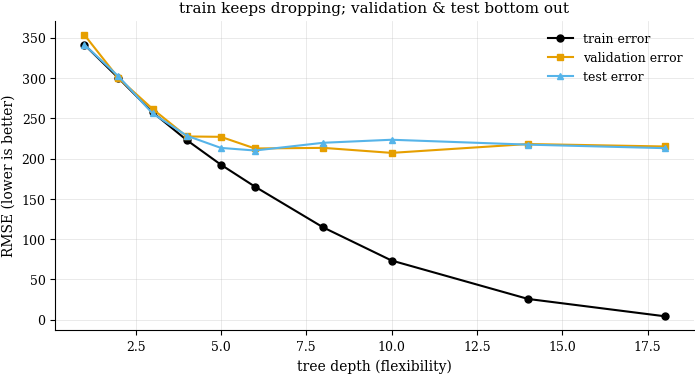

In [4]:
depths = [1, 2, 3, 4, 5, 6, 8, 10, 14, 18]
tr_e, va_e, te_e = [], [], []
for d in depths:
    m = make_pipe(d).fit(X_train, y_train)
    tr_e.append(rmse(m, X_train, y_train))
    va_e.append(rmse(m, X_val, y_val))
    te_e.append(rmse(m, X_test, y_test))
tr_e, va_e, te_e = map(np.array, (tr_e, va_e, te_e))

fig, ax = plt.subplots(figsize=(7.0, 3.8))
ax.plot(depths, tr_e, "o-", label="train error")
ax.plot(depths, va_e, "s-", label="validation error")
ax.plot(depths, te_e, "^-", label="test error")
ax.set_xlabel("tree depth (flexibility)"); ax.set_ylabel("RMSE (lower is better)")
ax.set_title("train keeps dropping; validation & test bottom out"); ax.legend(); ax.grid(alpha=0.3)
plt.show()

In [5]:
d_val  = depths[int(va_e.argmin())]     # depth chosen the HONEST way (on validation)
d_test = depths[int(te_e.argmin())]     # depth chosen the CHEATING way (on the test set)

print(f"depth chosen on VALIDATION : {d_val:2d}")
print(f"depth chosen on TEST       : {d_test:2d}")
print()
print(f"minimum test RMSE over the sweep      : {te_e.min():7.1f}   <- what 'tuning on test' would REPORT")
print(f"test RMSE at the validation choice    : {te_e[va_e.argmin()]:7.1f}   <- what we should report")

depth chosen on VALIDATION : 10
depth chosen on TEST       :  6

minimum test RMSE over the sweep      :   210.0   <- what 'tuning on test' would REPORT
test RMSE at the validation choice    :   223.4   <- what we should report


The "minimum test RMSE over the sweep" looks great &mdash; but it is a **lie by selection**. We
scanned ten models and reported the luckiest one *on the test set*. To prove it is luck, evaluate
both chosen models on **next month's fresh apartments** (data neither model &mdash; nor we &mdash; ever saw):

In [6]:
m_val  = make_pipe(d_val).fit(X_train, y_train)
m_test = make_pipe(d_test).fit(X_train, y_train)

print(f"model chosen on validation  ->  test RMSE {rmse(m_val, X_test, y_test):7.1f} | FRESH RMSE {rmse(m_val, X_fresh, y_fresh):7.1f}")
print(f"model chosen on the test set ->  test RMSE {rmse(m_test, X_test, y_test):7.1f} | FRESH RMSE {rmse(m_test, X_fresh, y_fresh):7.1f}")

model chosen on validation  ->  test RMSE   223.4 | FRESH RMSE   218.6
model chosen on the test set ->  test RMSE   210.0 | FRESH RMSE   212.9


> ⚠️ **The point.** The model tuned on the test set had a flatteringly low *test* number, but on
> **fresh** data it is **no better** than the honestly-chosen model &mdash; sometimes worse. Its low
> test score was selection luck, not skill. Meanwhile the validation-chosen model's test number
> *matches* its fresh number: it was **honest**. That is what a validation set buys you &mdash; a
> place to make all your choices so the test set stays an untouched, trustworthy final exam.

## 3. The winner's curse: selection manufactures illusions

Here is the most important experiment in this notebook. We build a dataset with **no signal at
all** &mdash; the labels are random coin flips, unrelated to the features. No model can do better
than 50% on new data, *by construction*. Yet watch what happens when we try **many** models and
keep the best one on a held-out set.

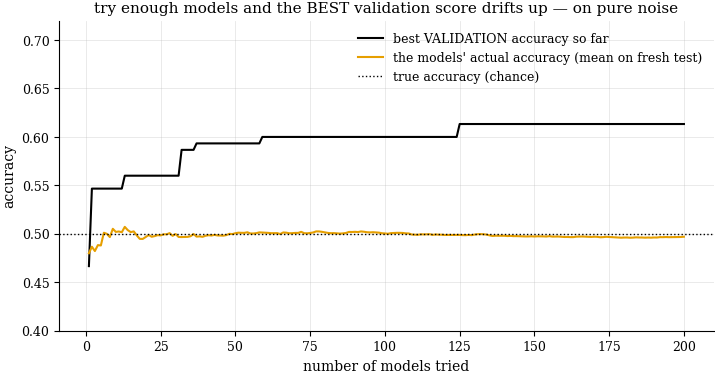

In [7]:
from sklearn.linear_model import LogisticRegression

n, d, K = 600, 40, 200          # 200 different models, each a random subset of 3 noise features

def try_many_models(seed):
    r = np.random.default_rng(seed)
    Xn = r.standard_normal((n, d))               # random features
    yn = r.permutation(np.tile([0, 1], n // 2))  # PURE NOISE: balanced labels, unrelated to X
    Xtr, Xr, ytr, yr = train_test_split(Xn, yn, test_size=0.5, random_state=seed)
    Xva, Xte, yva, yte = train_test_split(Xr, yr, test_size=0.5, random_state=seed)
    va = np.empty(K); te = np.empty(K)
    for k in range(K):
        cols = r.choice(d, 3, replace=False)     # each 'model' = a random 3-feature subset
        clf = LogisticRegression().fit(Xtr[:, cols], ytr)
        va[k] = clf.score(Xva[:, cols], yva)     # accuracy on the selection (validation) set
        te[k] = clf.score(Xte[:, cols], yte)     # accuracy on a fresh test set
    return va, te

va, te = try_many_models(seed=0)
best_val = np.maximum.accumulate(va)                        # best validation acc among the first k models
mean_test = np.cumsum(te) / np.arange(1, K + 1)            # the models' actual (test) accuracy so far

fig, ax = plt.subplots(figsize=(7.2, 3.8))
ax.plot(range(1, K+1), best_val, label="best VALIDATION accuracy so far")
ax.plot(range(1, K+1), mean_test, label="the models' actual accuracy (mean on fresh test)")
ax.axhline(0.5, color="k", ls=":", lw=1, label="true accuracy (chance)")
ax.set_xlabel("number of models tried"); ax.set_ylabel("accuracy")
ax.set_ylim(0.4, 0.72); ax.legend(fontsize=9); ax.grid(alpha=0.3)
ax.set_title("try enough models and the BEST validation score drifts up \u2014 on pure noise")
plt.show()

The best *validation* accuracy climbs well above 0.5 as we try more models &mdash; yet the models'
actual accuracy (on fresh test data) never leaves chance. To be sure this is not one lucky seed,
repeat the whole experiment on many independent noise datasets and look at the **selected**
model each time:

averaged over 40 independent pure-noise datasets (200 models each):
  best VALIDATION accuracy (what you'd report) : 0.594   <- looks like real skill!
  the SELECTED model's TEST accuracy (the truth): 0.492   <- chance; the data was noise


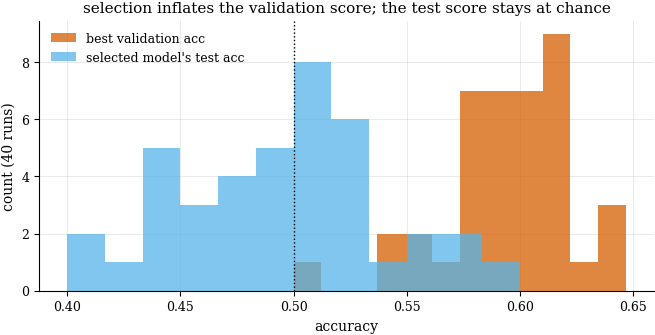

In [8]:
def selection_gap(seed):
    va, te = try_many_models(seed)
    b = int(va.argmax())            # pick the model that looks best on validation
    return va.max(), te[b]          # (its inflated validation score, its honest test score)

runs = np.array([selection_gap(s) for s in range(40)])
print(f"averaged over 40 independent pure-noise datasets ({K} models each):")
print(f"  best VALIDATION accuracy (what you'd report) : {runs[:,0].mean():.3f}   <- looks like real skill!")
print(f"  the SELECTED model's TEST accuracy (the truth): {runs[:,1].mean():.3f}   <- chance; the data was noise")

fig, ax = plt.subplots(figsize=(6.6, 3.4))
ax.hist(runs[:, 0], bins=12, alpha=0.75, color="#D55E00", label="best validation acc")
ax.hist(runs[:, 1], bins=12, alpha=0.75, color="#56B4E9", label="selected model's test acc")
ax.axvline(0.5, color="k", ls=":", lw=1)
ax.set_xlabel("accuracy"); ax.set_ylabel("count (40 runs)"); ax.legend(fontsize=9); ax.grid(alpha=0.3)
ax.set_title("selection inflates the validation score; the test score stays at chance")
plt.show()

> ⭐ **Key idea (why validation must be separate from test).** The more models you compare on a
> set, the more the best one's score on *that set* is inflated by luck &mdash; the **winner's curse**
> (a multiple-comparisons effect). Model selection is itself a kind of fitting, so the set you
> select on becomes optimistic. That is precisely why we select on **validation** and keep a
> pristine **test** set for the one honest number. Every extra peek at the test set spends a
> little of its honesty &mdash; it is a **non-renewable resource**.

## 4. The honest protocol, in three lines

1. **Fit** each candidate on **train**.
2. **Select** the best on **validation** (never on test).
3. **Refit** the winner on train+validation and report its score on **test** &mdash; **once**.

In [9]:
# 1 & 2: select depth on validation
best_depth = depths[int(np.argmin([rmse(make_pipe(d).fit(X_train, y_train), X_val, y_val) for d in depths]))]

# 3: refit on train+validation, evaluate ONCE on the untouched test set
final = make_pipe(best_depth).fit(X_dev, y_dev)     # X_dev = train + validation
print(f"selected depth (on validation): {best_depth}")
print(f"final, one-shot TEST RMSE     : {rmse(final, X_test, y_test):.1f}")
print(f"(sanity check on fresh data)  : {rmse(final, X_fresh, y_fresh):.1f}   <- close = the estimate was honest")

selected depth (on validation): 10
final, one-shot TEST RMSE     : 204.8
(sanity check on fresh data)  : 217.7   <- close = the estimate was honest


## 5. Cross-validation: a sturdier validation set

A single validation split has a problem: the score depends on *which* rows happened to land in
it. With little data that is noisy and wasteful. **k-fold cross-validation** fixes both: split
the development data into k folds, and let each fold take a turn as the validation set. Every row
is used for validation exactly once, and we average k scores for a stable estimate.

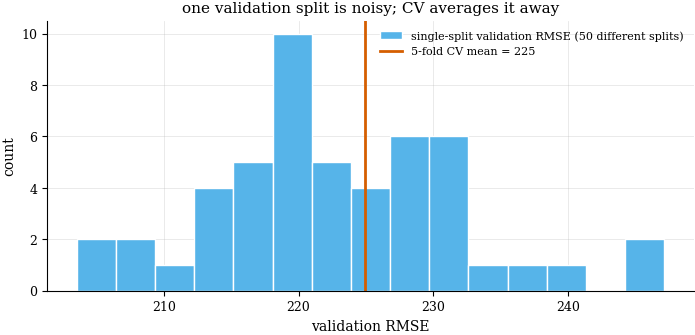

single-split RMSE ranges from 204 to 247 (spread 44)
5-fold CV per-fold RMSE: [213. 223. 240. 212. 236.]  ->  mean 225 +/- 12


In [10]:
from sklearn.model_selection import cross_val_score

# (a) how much does a SINGLE validation split wander as we change which rows it contains?
single = []
for s in range(50):
    Xa, Xb, ya, yb = train_test_split(X_dev, y_dev, test_size=0.25, random_state=s)
    single.append(rmse(make_pipe(6).fit(Xa, ya), Xb, yb))
single = np.array(single)

# (b) one 5-fold CV estimate on the same data
cv = -cross_val_score(make_pipe(6), X_dev, y_dev, cv=5, scoring="neg_root_mean_squared_error")

fig, ax = plt.subplots(figsize=(7.0, 3.4))
ax.hist(single, bins=15, color="#56B4E9", edgecolor="white", label="single-split validation RMSE (50 different splits)")
ax.axvline(cv.mean(), color="#D55E00", lw=2, label=f"5-fold CV mean = {cv.mean():.0f}")
ax.set_xlabel("validation RMSE"); ax.set_ylabel("count"); ax.legend(fontsize=8); ax.grid(alpha=0.3)
ax.set_title("one validation split is noisy; CV averages it away")
plt.show()
print(f"single-split RMSE ranges from {single.min():.0f} to {single.max():.0f} (spread {single.max()-single.min():.0f})")
print(f"5-fold CV per-fold RMSE: {np.round(cv,0)}  ->  mean {cv.mean():.0f} +/- {cv.std():.0f}")

> 🔬 **Going deeper.** Cross-validation replaces the *validation* split, not the *test* split.
> Typical choices: **k = 5 or 10**; **stratified** k-fold for classification (keep class balance
> in each fold); **`TimeSeriesSplit`** for time series (fold boundaries respect time, per 01b);
> **`GroupKFold`** when rows cluster (e.g. several photos of the same patient must not straddle
> folds). More folds ⇒ less bias, more compute.

## 6. Doing it for real: `GridSearchCV` + a final test

`GridSearchCV` automates "select on cross-validated validation": it tries every setting with
internal k-fold CV on the development data, then refits the best on all of it. We still keep the
test set for a single final score.

In [11]:
from sklearn.model_selection import GridSearchCV

grid = GridSearchCV(make_pipe(None), param_grid={"tree__max_depth": depths},
                    cv=5, scoring="neg_root_mean_squared_error")
grid.fit(X_dev, y_dev)                                  # selection happens entirely inside the dev set

print(f"best depth (CV-selected): {grid.best_params_['tree__max_depth']}")
print(f"best CV RMSE            : {-grid.best_score_:.1f}")
print(f"final one-shot TEST RMSE: {rmse(grid, X_test, y_test):.1f}")

best depth (CV-selected): 8
best CV RMSE            : 222.8
final one-shot TEST RMSE: 192.7


> 🔬 **Going deeper (nested CV).** `GridSearchCV`'s own `best_score_` is *slightly optimistic* &mdash;
> it is the winner of a selection, so it suffers a mild winner's curse. When you need an unbiased
> estimate **and** you are tuning, wrap the whole `GridSearchCV` inside an outer CV loop
> (`cross_val_score(grid, X, y, cv=...)`): the inner loop selects, the outer loop scores on data
> the selection never saw. That is **nested cross-validation** &mdash; the gold standard when you have
> no separate test set.

## 7. Ways the test set secretly leaks (checklist)

Every one of these quietly turns your test set into a validation set &mdash; and inflates your score:

* **Tuning on test:** choosing hyperparameters, features, the model, a decision threshold, or the
  stopping epoch by looking at test performance. (Section 2.)
* **Preprocessing before splitting:** fitting a scaler, imputer, or encoder on all the data.
  (01c.) Do it *inside* the pipeline. (01e.)
* **Reusing the test set many times:** run enough experiments against a fixed test set and you
  overfit *to it* by selection &mdash; the winner's curse again (why public leaderboards decay).
* **Duplicate or near-duplicate rows across splits:** the same (or almost the same) example in
  train and test. Deduplicate first (01c); use `GroupKFold` when rows cluster.
* **Time travel:** for time series, validation/test must be in the **future** of train
  (`TimeSeriesSplit`, per 01b) &mdash; never shuffle.
* **Target leakage:** a feature that encodes the answer (e.g. `rent_per_m2` when predicting
  rent). No split protects you from this &mdash; it needs a human check.

## Recap & exercises

**Recap.**
* **train** fits parameters, **validation** makes *every* choice, **test** gives *one* honest
  number. Look at test exactly once.
* **Tuning on the test set is optimistic:** the reported number won't hold on fresh data
  (section 2).
* **The winner's curse:** comparing many models on a set inflates the best one's score on that
  set &mdash; even on pure noise (section 3). This is *the* reason validation and test must differ.
* **Cross-validation** is a sturdier validation set (stable, data-efficient); it replaces the
  validation split, not the test split.
* Automate selection with **`GridSearchCV`**; use **nested CV** for an unbiased estimate while
  tuning.

**Exercises.**
1. In section 2, change the `random_state` of the splits and re-run. Do `d_val` and `d_test`
   still differ? Does the fresh-data conclusion hold?
2. In the winner's curse (section 3), set `K = 20`, `100`, `2000`. How high does the best
   *validation* accuracy climb, and does the *test* accuracy ever leave 0.5? What does that say
   about trying many models on a small validation set?
3. Give the noise data a tiny bit of real signal (`yn = (Xn[:,0] > 0).astype(int)` with some
   flips). Now does the best model beat chance on the test set? By how much versus its inflated
   validation score?
4. Replace the single 5-fold CV in section 5 with 10-fold and with 3-fold. How do the mean and
   spread change?
5. Wrap `grid` from section 6 in `cross_val_score(grid, X_dev, y_dev, cv=5)` (nested CV). Is the
   nested estimate higher or lower than `grid.best_score_`? Explain why.

*Next:* **01e &mdash; your first end-to-end ML pipeline**, which puts this discipline to work: a
leak-free `Pipeline`, cross-validated model selection, and a single honest test score.